# Linear Regression from Scratch
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Implementing Linear Regression with gradient descent from scratch and comparing against scikit-learn.

Main goals:

- Build a LinearRegression class using only NumPy.
- Implement the MSE cost function and its gradient.
- Plot cost convergence and check the effect of the learning rate.
- Compare fitted parameters and predictions against `sklearn.linear_model.LinearRegression`.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Synthetic Dataset

In [2]:
np.random.seed(42)
n = 200
X = np.random.uniform(0, 10, n)
true_w, true_b = 3.2, 5.0
y = true_w * X + true_b + np.random.normal(0, 2.0, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}')

Train: 160  Test: 40


## LinearRegression Class

In [3]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.w = 0.0
        self.b = 0.0
        self.cost_history = []

    def fit(self, X, y):
        m = len(X)
        for _ in range(self.n_iterations):
            y_pred = self.w * X + self.b
            cost = (1/m) * np.sum((y_pred - y) ** 2)
            self.cost_history.append(cost)

            dw = (2/m) * np.sum((y_pred - y) * X)
            db = (2/m) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self

    def predict(self, X):
        return self.w * X + self.b

In [4]:
model = LinearRegressionScratch(learning_rate=0.02, n_iterations=1000)
model.fit(X_train, y_train)

print(f'True w={true_w}, b={true_b}')
print(f'Fitted w={model.w:.4f}, b={model.b:.4f}')

True w=3.2, b=5.0
Fitted w=3.2210, b=5.0290


## Convergence Plot

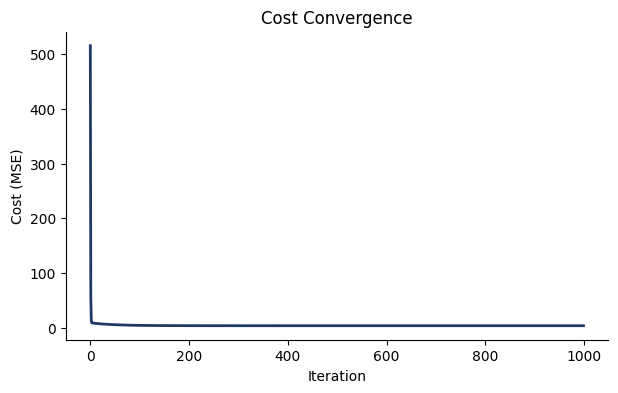

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(model.cost_history, color='#1F3864', lw=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost (MSE)')
ax.set_title('Cost Convergence')
plt.show()

## Learning Rate Effect

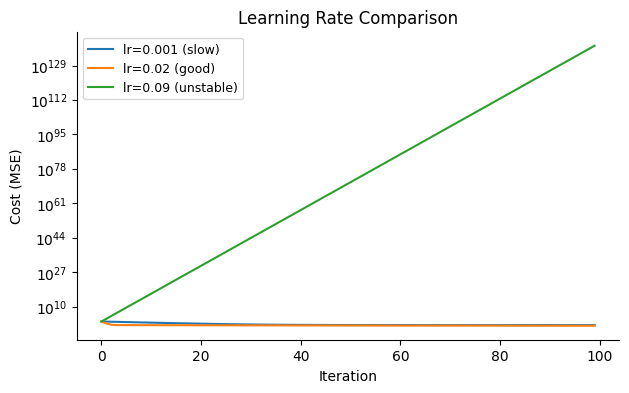

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for lr, label in [(0.001, 'lr=0.001 (slow)'), (0.02, 'lr=0.02 (good)'), (0.09, 'lr=0.09 (unstable)')]:
    m = LinearRegressionScratch(learning_rate=lr, n_iterations=100)
    m.fit(X_train, y_train)
    ax.plot(m.cost_history, label=label)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost (MSE)')
ax.set_yscale('log')
ax.set_title('Learning Rate Comparison')
ax.legend(fontsize=9)
plt.show()

**Observation:**
lr=0.09 causes the cost to oscillate and grow rather than settle — the update step overshoots the minimum each time. lr=0.001 converges but much more slowly than lr=0.02 in the same number of iterations.

## Predicted vs Actual

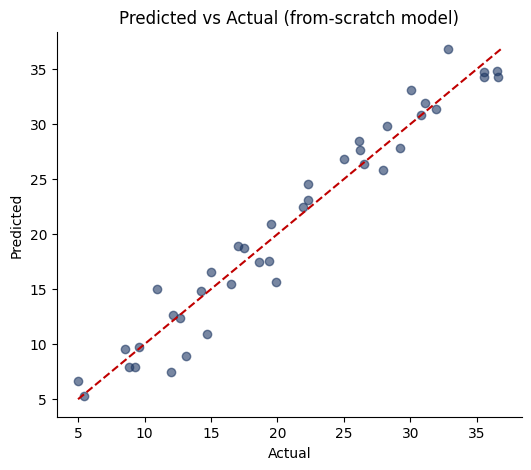

In [7]:
y_pred_scratch = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_scratch, alpha=0.6, color='#1F3864')
lims = [min(y_test.min(), y_pred_scratch.min()), max(y_test.max(), y_pred_scratch.max())]
ax.plot(lims, lims, '--', color='#C00000', lw=1.5)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual (from-scratch model)')
plt.show()

## Comparison with sklearn

In [8]:
sk_model = LinearRegression()
sk_model.fit(X_train.reshape(-1, 1), y_train)
y_pred_sklearn = sk_model.predict(X_test.reshape(-1, 1))

print(f'{"":15s}{"w":>10s}{"b":>10s}{"MSE":>12s}{"R2":>10s}')
print(f'{"Scratch":15s}{model.w:10.4f}{model.b:10.4f}'
      f'{mean_squared_error(y_test, y_pred_scratch):12.4f}{r2_score(y_test, y_pred_scratch):10.4f}')
print(f'{"sklearn":15s}{sk_model.coef_[0]:10.4f}{sk_model.intercept_:10.4f}'
      f'{mean_squared_error(y_test, y_pred_sklearn):12.4f}{r2_score(y_test, y_pred_sklearn):10.4f}')

                        w         b         MSE        R2
Scratch            3.2210    5.0290      4.3385    0.9484
sklearn            3.2209    5.0291      4.3385    0.9484


**Observation:**
w, b, MSE, and R2 are nearly identical between the scratch implementation and sklearn — sklearn uses a more efficient solver but converges to essentially the same line.